<a href="https://colab.research.google.com/github/amoghsbaviskar-bit/ML101/blob/main/day07to10/Day07to10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import os
import urllib.request
import gzip

# 1. Create a directory to hold the data if it doesn't exist
os.makedirs('.', exist_ok=True)

# 2. Define the base URL mirror for Yann LeCun's MNIST dataset
base_url = "https://ossci-datasets.s3.amazonaws.com/mnist/"

# 3. List the exact 4 binary files our pipeline needs
files = {
    "train-images.idx3-ubyte": "train-images-idx3-ubyte.gz",
    "train-labels.idx1-ubyte": "train-labels-idx1-ubyte.gz",
    "t10k-images.idx3-ubyte": "t10k-images-idx3-ubyte.gz",
    "t10k-labels.idx1-ubyte": "t10k-labels-idx1-ubyte.gz"
}

print("Checking dataset dependencies...")

for unzipped_name, zipped_name in files.items():
    if not os.path.exists(unzipped_name):
        print(f"📥 Downloading {unzipped_name} from cloud storage mirror...")

        # Download the compressed .gz file from the server
        url = base_url + zipped_name
        urllib.request.urlretrieve(url, zipped_name)

        # Uncompress the .gz file directly into our raw binary format
        with gzip.open(zipped_name, 'rb') as f_in:
            with open(unzipped_name, 'wb') as f_out:
                f_out.write(f_in.read())

        # Delete the temporary .gz file to keep our workspace clean
        os.remove(zipped_name)
        print(f"{unzipped_name} successfully extracted!")
    else:
        print(f"{unzipped_name} already exists. Skipping download.")

print("\n All data streams verified and ready for the pipeline!")

Checking dataset dependencies...
train-images.idx3-ubyte already exists. Skipping download.
train-labels.idx1-ubyte already exists. Skipping download.
t10k-images.idx3-ubyte already exists. Skipping download.
t10k-labels.idx1-ubyte already exists. Skipping download.

 All data streams verified and ready for the pipeline!


In [49]:
import torch as th
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset , DataLoader
import numpy as np
import matplotlib.pyplot as plt
import struct

class RawMNISTDataset(Dataset):
  def __init__(self, images_path, labels_path):
    super().__init__()
    with open(images_path , 'rb') as img_f:
      magic, num_images, rows, cols = struct.unpack(">IIII", img_f.read(16))
      raw_pixels = np.fromfile(img_f , dtype=np.uint8)
      self.images = th.from_numpy(raw_pixels).float().reshape(num_images, 1 , rows, cols)/255.0

    with open(labels_path , 'rb') as lbl_f:
      magic , num_labels = struct.unpack(">II", lbl_f.read(8))
      raw_labels = np.fromfile(lbl_f , dtype=np.uint8)
      self.labels = th.from_numpy(raw_labels).long()

  def __len__(self):
    return len(self.images)

  def __getitem__(self, idx):
    return self.images[idx] , self.labels[idx]

In [50]:
train_dataset = RawMNISTDataset('train-images.idx3-ubyte', 'train-labels.idx1-ubyte')
test_dataset =  RawMNISTDataset('t10k-images.idx3-ubyte', 't10k-labels.idx1-ubyte')

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True )
test_loader = DataLoader(test_dataset, batch_size=64, shuffle= False)

print(f" training samples successfully loaded:{len(train_dataset)}")
print(f" testing samples successfully loaded:{len(test_dataset)}")

images, labels = next(iter(train_loader))
print(f"Single batch img shape:{images.shape}")
print(f"single batch labels shape:{labels.shape}")


 training samples successfully loaded:60000
 testing samples successfully loaded:10000
Single batch img shape:torch.Size([64, 1, 28, 28])
single batch labels shape:torch.Size([64])


In [51]:
import torch as th
import torch.nn as nn

class MNISTClassifier(nn.Module):
    def __init__(self):
        super(MNISTClassifier, self).__init__()

        # 1. First Dense Layer: 784 input pixels map to 128 hidden processing neurons
        self.fc1 = nn.Linear(784, 128)

        # 2. Non-linear activation to let the network learn curvy features
        self.relu = nn.ReLU()

        # 3. Output Dense Layer: 128 hidden features map to 10 class logits (0-9)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Incoming tensor shape x: [64, 1, 28, 28]

        # Step 1: Flatten the 2D grid into a 1D vector.
        # CRITICAL: start_dim=1 protects our batch size dimension from getting flattened!
        x = th.flatten(x, start_dim=1)
        # New shape of x: [64, 784]

        # Step 2: Forward pass through our hidden layer and activation
        x = self.fc1(x)
        x = self.relu(x)
        # Shape after fc1: [64, 128]

        # Step 3: Compute final classification scores
        logits = self.fc2(x)
        # Final shape of logits: [64, 10]

        return logits

# Instantiate the architecture and print its structural outline
model = MNISTClassifier()
print(model)

MNISTClassifier(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [52]:
# 1. Grab a real batch of 64 images from your train_loader
images, labels = next(iter(train_loader))

# 2. Pass the images through your model's brain
logits = model(images)

# 3. Check the output dimensions
print("Input Batch Shape:", images.shape)
print("Model Output Logits Shape:", logits.shape)
print("\nFirst image's raw unnormalized scores (logits):\n", logits[0].detach())

Input Batch Shape: torch.Size([64, 1, 28, 28])
Model Output Logits Shape: torch.Size([64, 10])

First image's raw unnormalized scores (logits):
 tensor([-0.0085, -0.1358, -0.0464,  0.1369,  0.0133,  0.0364, -0.1076, -0.0751,
        -0.1059, -0.0732])


In [53]:
import torch.optim as optim

# 1. Instantiate the Multi-Class Loss Function (The Teacher)
criterion = nn.CrossEntropyLoss()

# 2. Instantiate the Adaptive Optimizer (The Mechanic)
# We hand it our model's weights and set a standard learning rate of 0.001
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Calculate the loss on your current batch to prove it works!
loss = criterion(logits, labels)

print(" Loss Engine & Optimizer successfully initialized!")
print(f" Initial Uncalculated Loss Score for this batch: {loss.item():.4f}")

 Loss Engine & Optimizer successfully initialized!
 Initial Uncalculated Loss Score for this batch: 2.3265


In [54]:
import time

# 1. Define how many times the model looks at the entire 60,000 image library
epochs = 3

print(" Initiating Day 10 Training Loop across 60,000 images...")
print("==========================================================")

for epoch in range(epochs):
    model.train() # Tell the model it is in training mode

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    start_time = time.time()

    # Loop over the shuffled mini-batches from our Day 7 loader
    for batch_idx, (images, labels) in enumerate(train_loader):

        # 1. Wipe out old memory gradients from the previous batch
        optimizer.zero_grad()

        # 2. Forward Pass: Run the 64 images through the network layers
        logits = model(images)

        # 3. Calculate the Error Score (Cross-Entropy evaluation)
        loss = criterion(logits, labels)

        # 4. Backward Pass: Calculate adjustments via Backpropagation
        loss.backward()

        # 5. Mechanical Adjustment: Adam updates all internal weights
        optimizer.step()

        # Accumulate metrics for our status reports
        running_loss += loss.item() * images.size(0)
        predictions = th.argmax(logits, dim=1)
        correct_predictions += (predictions == labels).sum().item()
        total_samples += labels.size(0)

    # Calculate Epoch statistics
    epoch_loss = running_loss / total_samples
    epoch_accuracy = (correct_predictions / total_samples) * 100
    elapsed_time = time.time() - start_time

    print(f" Epoch {epoch+1}/{epochs} Complete")
    print(f"    Loss: {epoch_loss:.4f} |  Training Accuracy: {epoch_accuracy:.2f}% | Time: {elapsed_time:.2f}s")
    print("----------------------------------------------------------")

print(" Training complete! The model's brain is officially optimized.")

 Initiating Day 10 Training Loop across 60,000 images...
 Epoch 1/3 Complete
    Loss: 0.3464 |  Training Accuracy: 90.61% | Time: 3.09s
----------------------------------------------------------
 Epoch 2/3 Complete
    Loss: 0.1576 |  Training Accuracy: 95.50% | Time: 3.15s
----------------------------------------------------------
 Epoch 3/3 Complete
    Loss: 0.1082 |  Training Accuracy: 96.84% | Time: 2.74s
----------------------------------------------------------
 Training complete! The model's brain is officially optimized.


In [61]:
# 1. Squish the raw logits into clean probabilities (0.0 to 1.0)
probabilities = th.softmax(logits, dim=1)

# 2. Filter the responses to grab the absolute highest index for each image
predictions = th.argmax(logits, dim=1)

# 3. Print the results for the very first image in our batch
print(" Definite Predicted Class (The Winner):", predictions[0].item())
print("True Target Class (The Answer Key):", labels[0].item())

print("\n Complete Confidence Breakdown for this image:")
for digit, prob in enumerate(probabilities[0]):
    print(f"   Digit {digit}: {prob.item() * 100:.2f}% confident")

 Definite Predicted Class (The Winner): 6
True Target Class (The Answer Key): 6

 Complete Confidence Breakdown for this image:
   Digit 0: 0.04% confident
   Digit 1: 0.00% confident
   Digit 2: 0.01% confident
   Digit 3: 0.00% confident
   Digit 4: 0.01% confident
   Digit 5: 0.01% confident
   Digit 6: 99.93% confident
   Digit 7: 0.00% confident
   Digit 8: 0.00% confident
   Digit 9: 0.00% confident


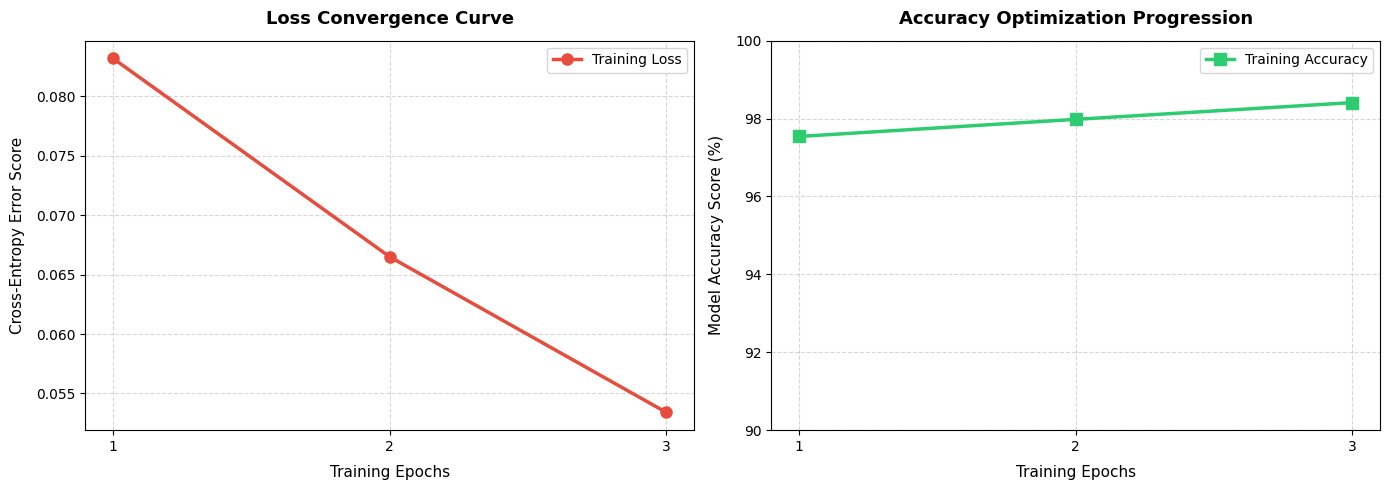

In [62]:
import matplotlib.pyplot as plt

# 1. Input the exact historical metrics from your optimized training run
epochs_range = [1, 2, 3]
losses = [0.0832, 0.0665, 0.0534]
accuracies = [97.54, 97.98, 98.41]

# 2. Initialize a dual-panel visualization grid
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left Panel: Cross-Entropy Loss Convergence ---
ax1.plot(epochs_range, losses, marker='o', color='#e74c3c', linewidth=2.5, markersize=8, label='Training Loss')
ax1.set_title('Loss Convergence Curve', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Training Epochs', fontsize=11, labelpad=8)
ax1.set_ylabel('Cross-Entropy Error Score', fontsize=11, labelpad=8)
ax1.set_xticks(epochs_range)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(fontsize=10)

# --- Right Panel: Accuracy Optimization Curve ---
ax2.plot(epochs_range, accuracies, marker='s', color='#2ecc71', linewidth=2.5, markersize=8, label='Training Accuracy')
ax2.set_title('Accuracy Optimization Progression', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Training Epochs', fontsize=11, labelpad=8)
ax2.set_ylabel('Model Accuracy Score (%)', fontsize=11, labelpad=8)
ax2.set_xticks(epochs_range)
ax2.set_ylim(90, 100) # Zoom in closely to track the high-tier precision gains
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(fontsize=10)

# Cleanly arrange spacing layout and render inline
plt.tight_layout()
plt.show()

🖼️ Generating test prediction visualization grid...


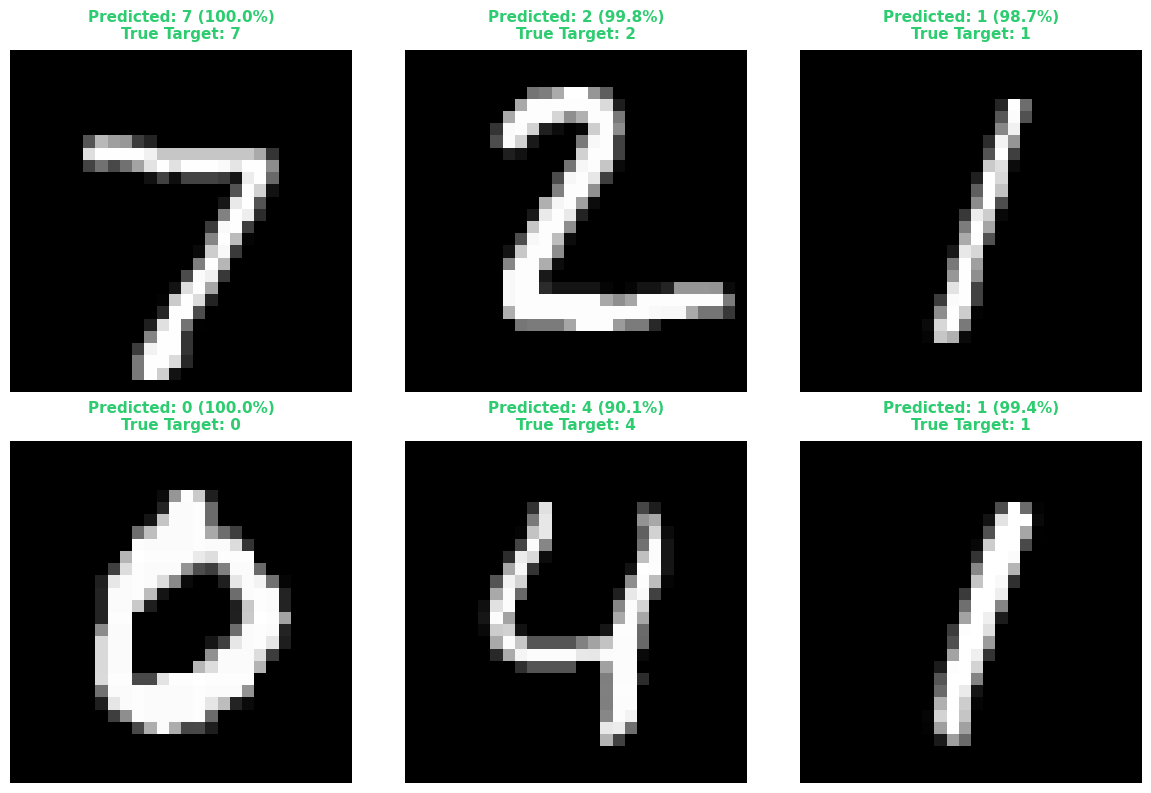

In [63]:
import torch as th
import matplotlib.pyplot as plt

# 1. Place the network architecture into evaluation mode
model.eval()

# 2. Extract a single batch of 64 images from your unseen test data stream
test_images, test_labels = next(iter(test_loader))

# 3. Deactivate the gradient tracking engine to preserve graphics memory
with th.no_grad():
    test_logits = model(test_images)
    test_probabilities = th.softmax(test_logits, dim=1)
    test_predictions = th.argmax(test_logits, dim=1)

# 4. Construct an image canvas grid for 6 random test visual cases
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

print("🖼️ Generating test prediction visualization grid...")

for i in range(6):
    # Unpack the image sample, converting the multi-dimensional tensor back into a 2D pixel array
    pixel_grid = test_images[i].squeeze().numpy()
    true_class = test_labels[i].item()
    predicted_class = test_predictions[i].item()
    confidence_score = test_probabilities[i][predicted_class].item() * 100

    # Render the pixel intensities as a monochrome digit image
    axes[i].imshow(pixel_grid, cmap='gray')

    # Apply context-driven conditional coloring for visual audit checks
    text_color = '#2ecc71' if predicted_class == true_class else '#e74c3c'

    # Establish descriptive tracking label strings
    status_label = f"Predicted: {predicted_class} ({confidence_score:.1f}%)\nTrue Target: {true_class}"
    axes[i].set_title(status_label, fontsize=11, color=text_color, fontweight='bold', pad=8)

    # Strip out standard axis charts for a clean interface display
    axes[i].axis('off')

plt.tight_layout()
plt.show()